# OpenAI compute Monte Carlo

Turns the single medians of `archive/openai_power_model.ipynb` into full distributions
by sampling the six main sources of uncertainty together:

1. **`new_chip_share`** — the chip-mix knob. The share of OpenAI's power placed
   on the *newest* year's deployment mix; the rest follows the *default*
   vintage-layered mix. At 0 the fleet is the default mix; at 1 it is entirely
   the latest mix.
2. **Deployment lag** — Nvidia books revenue when chips ship; they go live some
   quarters later. The lag controls which Microsoft snapshot each year reads.
3. **Power definition factor** — is each disclosed figure IT power or gross
   (facility) power? One shared multiplier: 80% chance it's already IT (a small
   residual band around 1.0), 20% chance it's gross (divided by a 1.1–1.7
   datacenter PUE, a downward haircut). This is the gap between the disclosed
   number and effective IT power, and it can only pull the total down.
4. **Rounding jitter** — each disclosure is reported to the nearest 0.1 GW, so
   the true value sits within ±50 MW. Modeled as a triangular peaked at 0, since
   the exact edges are less likely. Same band for every year, so 2025 (1.9 GW)
   is the most precise in relative terms and 2023 (0.2 GW) the least.
5. **IT overhead factor** — watts per GPU is server power times an IT overhead
   (networking, storage, management). We vary that overhead: median 1.14, 5th–95th
   ~1.0–1.35, floored at 1.0 (from the Colossus data-center calculations). Higher
   overhead means fewer chips per disclosed MW, so it moves the total both ways —
   a low overhead is the model's main upside lever.
6. **Figure accuracy** — is OpenAI's internal total-power number itself right,
   setting aside rounding and the IT-vs-gross question? Undercounted providers
   or newly-online capacity push the true figure up; overstatement pushes it
   down. One shared draw, 90% range 0.9–1.2 (median ~1.04, a mild upward lean).

H100e per GPU is still held fixed. With `new_chip_share = 0`, lag = 0, nominal
power, and the median IT overhead, the model reproduces the deterministic
`archive/openai_power_model.ipynb` reference.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squigglepy as sq

N_SAMPLES = 5000
sq.set_seed(42)  # squigglepy has its own RNG; np.random.seed does not affect it

CHIP_TYPES = ['A100', 'H100/H200', 'B200', 'B300']
CHIP_COLORS = {'A100': '#8b5cf6', 'H100/H200': '#76b900', 'B200': '#1a73e8', 'B300': '#e8710a'}
CHIP_LABELS = {'A100': 'A100', 'H100/H200': 'H100/H200', 'B200': 'B200 (GB200)', 'B300': 'B300 (GB300)'}


def fmt(value):
    """Format an H100e or chip count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

## Canonical parameters

The sampled priors are loaded from `lab_model_params.csv` — the single source
of truth shared with the other lab notebooks and `frontier_lab_compute_model.py`.
Edit the sheet (leaving a note in its description column) to change a prior.
The sensitivity sweeps in sections 6–8 build local variants and don't touch it.

In [2]:
import sys
if not Path('lab_compute_utils.py').exists():
    sys.path.append(str(Path('ai-lab-compute').resolve()))  # allow running from the repo root
from lab_compute_utils import load_lab_params, lab_params_table

_ALL_PARAMS = load_lab_params()
PARAMS = _ALL_PARAMS['openai']
IT_OVERHEAD = _ALL_PARAMS['chip_specs']['nvidia_it_overhead']  # server power -> IT power per GPU
lab_params_table('openai')

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,new_chip_share,beta,2.00,6.00,NaN,NaN,share,Share of fleet refreshed to the newest chip mi...,7/2/26
1,lag_quarters,to,0.50,2.00,NaN,NaN,quarters,Deployment lag used to read Microsoft's chip m...,7/2/26
2,if_it_power,to,0.95,1.05,NaN,NaN,multiplier,Residual definitional noise if the disclosed f...,7/2/26
3,gross_pue,to,1.10,1.70,NaN,NaN,ratio,Datacenter PUE divisor applied if the disclose...,7/2/26
4,p_gross,const,0.20,NaN,NaN,NaN,probability,Probability the disclosures are gross rather t...,7/2/26
5,figure_accuracy,to,0.90,1.20,NaN,NaN,multiplier,Accuracy of OpenAI's internal total-power figu...,7/8/26
6,rounding_mw,const,50.00,NaN,NaN,NaN,MW,Half-step of the disclosures' 0.1 GW rounding:...,7/8/26


## 1. Load the data and derive model inputs

Three CSVs (the same ones the main model uses) give us: OpenAI's disclosed
power per year, Microsoft's fleet over time, and IT power per chip.

In [3]:
data_dir = Path('ai-lab-compute/data') if Path('ai-lab-compute/data').exists() else Path('data')

owners_df = pd.read_csv(data_dir / 'nvidia_owners_cumulative_by_chip.csv')
chip_power_df = pd.read_csv(data_dir / 'IT power by chip.csv')
openai_df = pd.read_csv(data_dir / 'lab IT power.csv')
openai_df['Date'] = pd.to_datetime(openai_df['Date'], format='%m/%d/%y')

# Watts per GPU = server power per GPU x IT overhead factor. We read the server
# power per GPU (fixed hardware) and vary the overhead (sampled below). The CSV
# names Blackwell parts "GB200"/"GB300"; the fleet data calls them "B200"/"B300".
power_csv_to_chip_name = {'A100': 'A100', 'H100': 'H100/H200', 'GB200': 'B200', 'GB300': 'B300'}
server_power_per_gpu = {
    power_csv_to_chip_name[row['Chip type']]: row['Server power per GPU (W)']
    for _, row in chip_power_df.iterrows()
    if row['Chip type'] in power_csv_to_chip_name
}
# Median watts per GPU (server power x the overhead's median). These drive the
# chip-mix shares, which a shared overhead scales uniformly and so leaves unchanged;
# only the final MW->count conversion feels the sampled overhead.
OVERHEAD_MEDIAN = float(np.median(IT_OVERHEAD @ 20000))
watts_per_gpu = {chip: server_power_per_gpu[chip] * OVERHEAD_MEDIAN for chip in CHIP_TYPES}

# Microsoft's cumulative fleet, every quarter, as (date x chip type) tables.
microsoft = owners_df[
    (owners_df['Owner'] == 'Microsoft') & (owners_df['Chip type'].isin(CHIP_TYPES))
].copy()
microsoft['End date'] = pd.to_datetime(microsoft['End date'])

microsoft_units = (
    microsoft.pivot_table(index='End date', columns='Chip type', values='Number of Units', aggfunc='first')
    .reindex(columns=CHIP_TYPES).fillna(0).sort_index()
)
microsoft_h100e = (
    microsoft.pivot_table(index='End date', columns='Chip type',
                          values='Compute estimate in H100e (median)', aggfunc='first')
    .reindex(columns=CHIP_TYPES).fillna(0).sort_index()
)

# The OpenAI disclosure dates (year-ends) are the model's time steps.
OPENAI_DATES = list(pd.to_datetime(openai_df['Date'].sort_values().unique()))

# H100e per GPU is a hardware ratio (roughly constant over time); read it off
# Microsoft's latest snapshot. Held fixed throughout.
last_date = OPENAI_DATES[-1]
h100e_per_gpu = {
    chip: (microsoft_h100e.loc[last_date, chip] / microsoft_units.loc[last_date, chip])
    if microsoft_units.loc[last_date, chip] > 0 else 0.0
    for chip in CHIP_TYPES
}

# Microsoft's cumulative IT power (MW) by chip, across every quarter.
microsoft_power = (microsoft_units * pd.Series(watts_per_gpu) / 1e6).sort_index()

# OpenAI's disclosed power per year, and the new power added each year.
disclosed_power_mw = {d: float(p) for d, p in zip(OPENAI_DATES, openai_df.sort_values('Date')['Total IT power (MW)'])}
power_added_mw = {}
previous = 0.0
for date in OPENAI_DATES:
    power_added_mw[date] = disclosed_power_mw[date] - previous
    previous = disclosed_power_mw[date]

overhead_pct = sq.get_percentiles(IT_OVERHEAD @ 50000, [5, 50, 95])
print(f'IT overhead factor (5th/median/95th): {overhead_pct[5]:.2f} / {overhead_pct[50]:.2f} / {overhead_pct[95]:.2f}')
print('Watts per GPU (5th / median / 95th), server power x overhead:')
for chip in CHIP_TYPES:
    s = server_power_per_gpu[chip]
    print(f'   {chip:10s} {s * overhead_pct[5]:,.0f} / {s * overhead_pct[50]:,.0f} / {s * overhead_pct[95]:,.0f} W')
print('H100e per GPU (fixed): ', {c: round(v, 2) for c, v in h100e_per_gpu.items()})
print('Disclosed power (MW):  ', {d.strftime('%Y'): int(p) for d, p in disclosed_power_mw.items()})

IT overhead factor (5th/median/95th): 1.00 / 1.14 / 1.35
Watts per GPU (5th / median / 95th), server power x overhead:
   A100       812 / 926 / 1,097 W
   H100/H200  1,275 / 1,453 / 1,721 W
   B200       1,833 / 2,089 / 2,475 W
   B300       1,944 / 2,215 / 2,625 W
H100e per GPU (fixed):  {'A100': 0.32, 'H100/H200': 1.0, 'B200': 2.53, 'B300': 2.53}
Disclosed power (MW):   {'2023': 200, '2024': 600, '2025': 1900}


## 2. The model

The whole model rests on Microsoft's deployment mix — the share of newly added
power going to each chip type each year. We build two versions of OpenAI's
fleet from it:

- **default** — vintage-layered: each year's added power keeps the mix Microsoft
  was deploying then, and carries forward. This is the main model.
- **newest** — the entire fleet placed on the most recent year's mix.

`new_chip_share` blends the two. The chosen mix is then scaled by OpenAI's
total power to get megawatts per chip, then chip counts, then H100e.

The **deployment lag** shifts the dates at which we read Microsoft's fleet.
Because Microsoft's data is quarterly, we just interpolate its cumulative power
to whatever (possibly fractional) date a sampled lag implies — `np.interp`
does this for the entire sample array at once, so no lookup grid is needed.

In [4]:
QUARTER_DAYS = 365.25 / 4
series_start = microsoft_power.index[0]
microsoft_day = np.array([(d - series_start).days for d in microsoft_power.index], dtype=float)
openai_day = {date: (date - series_start).days for date in OPENAI_DATES}


def microsoft_power_on(day, chip):
    """Microsoft's cumulative IT power (MW) for one chip, interpolated to any day.
    Accepts a scalar or an array of days. Lags before the data start clamp to the
    earliest snapshot."""
    return np.interp(day, microsoft_day, microsoft_power[chip].values)


def chip_power_shares(lag_quarters):
    """For each OpenAI year, the share of total power on each chip type, under a
    given deployment lag. Returns (default_shares, newest_shares), each a
    {date: {chip: share}} dict whose chip shares sum to 1.

    lag_quarters may be a scalar or an array (one value per Monte Carlo sample);
    every share comes back the same shape.
    """
    lag_days = lag_quarters * QUARTER_DAYS

    # Microsoft's cumulative power by chip, as seen `lag` quarters before each date.
    cumulative = {
        date: {chip: microsoft_power_on(openai_day[date] - lag_days, chip) for chip in CHIP_TYPES}
        for date in OPENAI_DATES
    }

    # The mix of power Microsoft *added* in each step: cumulative for the first
    # step (so legacy A100s are counted), incremental afterward.
    added_mix = {}
    for i, date in enumerate(OPENAI_DATES):
        if i == 0:
            added = {chip: np.maximum(cumulative[date][chip], 0.0) for chip in CHIP_TYPES}
        else:
            prev = OPENAI_DATES[i - 1]
            added = {chip: np.maximum(cumulative[date][chip] - cumulative[prev][chip], 0.0) for chip in CHIP_TYPES}
        total = sum(added.values())
        added_mix[date] = {chip: added[chip] / total for chip in CHIP_TYPES}

    # Default carries each year's additions forward at their own mix; newest uses
    # the latest year's mix for the whole fleet.
    default_shares, newest_shares = {}, {}
    carried_power = {chip: 0.0 for chip in CHIP_TYPES}
    for date in OPENAI_DATES:
        for chip in CHIP_TYPES:
            carried_power[chip] = carried_power[chip] + power_added_mw[date] * added_mix[date][chip]
        carried_total = sum(carried_power.values())
        default_shares[date] = {chip: carried_power[chip] / carried_total for chip in CHIP_TYPES}
        newest_shares[date] = added_mix[date]
    return default_shares, newest_shares


def run_monte_carlo(new_chip_share, lag_quarters, total_power, it_overhead):
    """Per-year, per-chip chip counts and H100e for the given parameter samples
    (each argument is a length-N array; total_power is a {date: array} dict).
    Watts per GPU = server power per GPU x it_overhead, one shared overhead per
    sample; a higher overhead means fewer chips bought per disclosed MW."""
    default_shares, newest_shares = chip_power_shares(lag_quarters)
    results = {}
    for date in OPENAI_DATES:
        counts, h100e = {}, {}
        for chip in CHIP_TYPES:
            # Blend the two mixes, then size the result by OpenAI's total power.
            share = (1 - new_chip_share) * default_shares[date][chip] + new_chip_share * newest_shares[date][chip]
            megawatts = total_power[date] * share
            counts[chip] = megawatts * 1e6 / (server_power_per_gpu[chip] * it_overhead)
            h100e[chip] = counts[chip] * h100e_per_gpu[chip]
        results[date] = {
            'counts': counts,
            'h100e': h100e,
            'total_counts': sum(counts.values()),
            'total_h100e': sum(h100e.values()),
        }
    return results


# How the newest-year power mix shifts as the lag grows (more lag -> older mix).
print('Newest-year power mix at', last_date.strftime('%Y'), 'by deployment lag:')
for lag in [0.0, 1.0, 2.0]:
    _, newest = chip_power_shares(lag)
    shares = ', '.join(f'{c} {newest[last_date][c] * 100:.0f}%' for c in CHIP_TYPES if newest[last_date][c] > 0.005)
    print(f'   {lag:.0f}Q lag: {shares}')

Newest-year power mix at 2025 by deployment lag:
   0Q lag: H100/H200 14%, B200 46%, B300 39%
   1Q lag: H100/H200 31%, B200 47%, B300 23%
   2Q lag: H100/H200 51%, B200 41%, B300 8%


## 3. Parameters and sampling

- **`new_chip_share`** — baseline prior `Beta(2,6)` (mean 0.25): most capacity
  sits on longer contracts that don't refresh to the newest chips. Section 6
  sweeps alternatives.
- **Deployment lag** — lognormal, 90% range 0.5–2 quarters (median 1).
- **Power definition factor** — is each disclosed figure IT power or gross?
  80% IT (a small residual band around 1.0), 20% gross (divided by a 1.1–1.7
  PUE). One shared draw across years, since it reflects how OpenAI reports.
- **Rounding jitter** — triangular ±50 MW per year, peaked at 0 (the 0.1 GW
  rounding step; the exact edges are less likely than a flat band).
- **IT overhead factor** — server power → IT power per GPU, median 1.14, 90% range
  ~1.0–1.35 (floored at 1.0). One shared draw; a lever with real upside.
- **Figure accuracy** — is the internal total-power number itself right? 90%
  range 0.9–1.2 (median ~1.04): undercounted providers push up, overstatement
  down. One shared draw, like the definition factor.

In [5]:
new_chip_share_prior = PARAMS['new_chip_share']
lag_prior = PARAMS['lag_quarters']

# Is each disclosed figure IT power, or gross (facility) power? P_GROSS is the
# gross probability. This is the definitional uncertainty — separate from the
# rounding jitter below, which is about precision.
if_it_power = PARAMS['if_it_power']       # already IT: small residual definitional noise
if_gross_power = 1 / PARAMS['gross_pue']  # gross: convert to IT by dividing by datacenter PUE
P_GROSS = PARAMS['p_gross']
power_definition_factor = sq.mixture([if_it_power, if_gross_power], [1 - P_GROSS, P_GROSS])

# Is OpenAI's internal total-power figure itself accurate, setting aside rounding
# and the IT-vs-gross question? Undercounted providers or newly-online capacity
# push the true figure up; overstatement pushes it down.
figure_accuracy_prior = PARAMS['figure_accuracy']

ROUNDING_MW = PARAMS['rounding_mw']  # half-step of the disclosures' 0.1 GW rounding


def sample_total_power(n):
    """Total power per year: each disclosure plus its own rounding jitter, times
    two shared factors — the power-definition factor (IT vs gross) and the
    figure-accuracy factor (is the internal number itself right). Both are drawn
    once per sample, since they reflect how OpenAI reports; the jitter is
    independent per year and peaks at zero."""
    definition_factor = power_definition_factor @ n
    accuracy_factor = figure_accuracy_prior @ n
    return {
        date: (disclosed_power_mw[date] + (sq.triangular(-ROUNDING_MW, 0, ROUNDING_MW) @ n))
        * definition_factor * accuracy_factor
        for date in OPENAI_DATES
    }


# Central values, used to hold a parameter still while isolating another (section 5).
new_chip_share_central = float(np.median(new_chip_share_prior @ 20000))
lag_central = 1.0  # geometric mean of the 0.5–2.0 quarter range

print(f'new_chip_share central (median): {new_chip_share_central:.2f}')
print(f'deployment lag central (median): {lag_central:.2f} quarters')

new_chip_share central (median): 0.23
deployment lag central (median): 1.00 quarters


## 4. Run the Monte Carlo

All six inputs vary together, so each sample is one coherent scenario.

In [6]:
new_chip_share = new_chip_share_prior @ N_SAMPLES
lag_quarters = lag_prior @ N_SAMPLES
total_power = sample_total_power(N_SAMPLES)
it_overhead = IT_OVERHEAD @ N_SAMPLES

mc = run_monte_carlo(new_chip_share, lag_quarters, total_power, it_overhead)

# Deterministic reference: new_chip_share 0, no lag, nominal power, median overhead = the main model.
reference = run_monte_carlo(
    np.array([0.0]), np.array([0.0]), {d: np.array([disclosed_power_mw[d]]) for d in OPENAI_DATES},
    np.array([OVERHEAD_MEDIAN]))
reference_h100e = {d: reference[d]['total_h100e'][0] for d in OPENAI_DATES}

print('Total H100e by year (5th / median / 95th), and the main-model reference:')
for date in OPENAI_DATES:
    lo, mid, hi = percentiles(mc[date]['total_h100e'])
    print(f'   {date.strftime("%Y")}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}   (reference {fmt(reference_h100e[date])})')

# Chip-mix composition at the latest date.
a100_share = mc[last_date]['counts']['A100'] / mc[last_date]['total_counts']
blackwell_share = (mc[last_date]['counts']['B200'] + mc[last_date]['counts']['B300']) / mc[last_date]['total_counts']
print(f'\n{last_date.strftime("%Y")} chip-count shares (5th / median / 95th):')
print(f'   A100:      {" / ".join(f"{v:.0%}" for v in percentiles(a100_share))}')
print(f'   Blackwell: {" / ".join(f"{v:.0%}" for v in percentiles(blackwell_share))}')

Total H100e by year (5th / median / 95th), and the main-model reference:
   2023: 66k / 100k / 134k   (reference 111k)
   2024: 260k / 387k / 490k   (reference 408k)
   2025: 1.18M / 1.76M / 2.23M   (reference 1.85M)

2025 chip-count shares (5th / median / 95th):
   A100:      5% / 8% / 10%
   Blackwell: 28% / 42% / 52%


## 5. Results

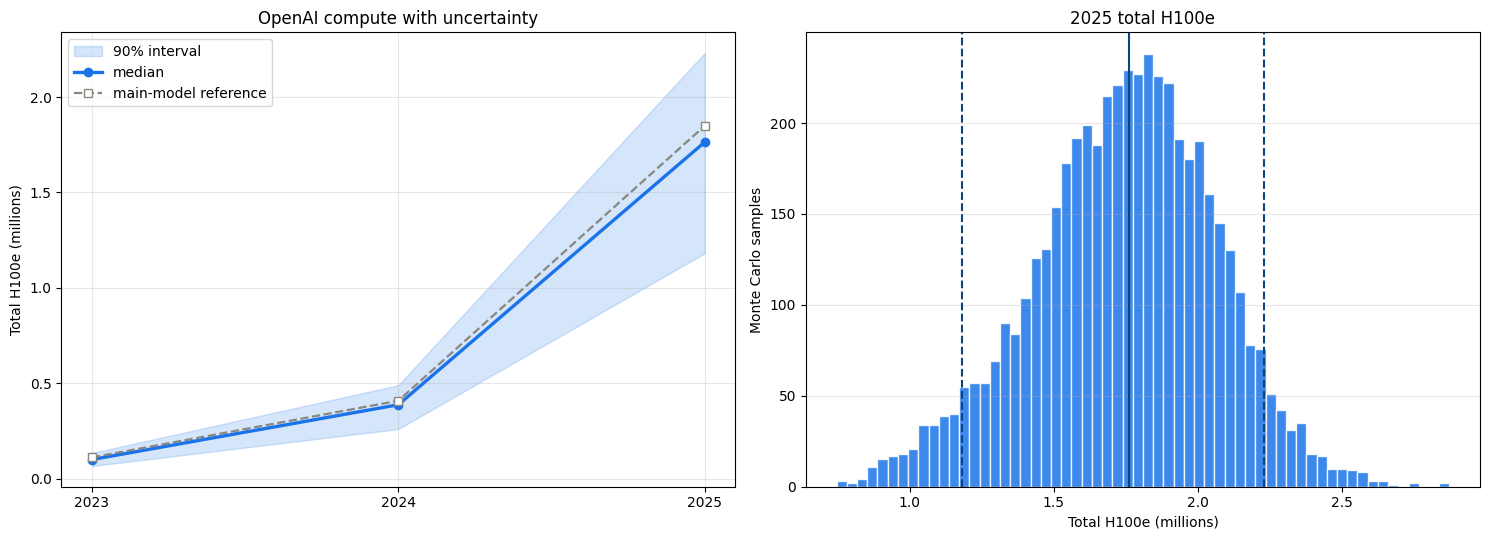

In [7]:
fig, (ax_years, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: total H100e by year, with its 90% interval and the main-model reference.
years = [d.year for d in OPENAI_DATES]
median_by_year = [np.median(mc[d]['total_h100e']) / 1e6 for d in OPENAI_DATES]
low_by_year = [percentiles(mc[d]['total_h100e'])[0] / 1e6 for d in OPENAI_DATES]
high_by_year = [percentiles(mc[d]['total_h100e'])[2] / 1e6 for d in OPENAI_DATES]
reference_by_year = [reference_h100e[d] / 1e6 for d in OPENAI_DATES]

ax_years.fill_between(years, low_by_year, high_by_year, color='#1a73e8', alpha=0.18, label='90% interval')
ax_years.plot(years, median_by_year, color='#1a73e8', lw=2.4, marker='o', label='median')
ax_years.plot(years, reference_by_year, color='#888780', lw=1.6, ls='--', marker='s',
              markerfacecolor='white', label='main-model reference')
ax_years.set_title('OpenAI compute with uncertainty', fontsize=12)
ax_years.set_ylabel('Total H100e (millions)')
ax_years.set_xticks(years)
ax_years.legend()
ax_years.grid(True, alpha=0.3)

# Right: distribution of the latest-year total.
latest_samples = mc[last_date]['total_h100e'] / 1e6
ax_hist.hist(latest_samples, bins=60, color='#1a73e8', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(mc[last_date]['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#0c447c', ls=style, lw=1.5)
ax_hist.set_title(f'{last_date.strftime("%Y")} total H100e', fontsize=12)
ax_hist.set_xlabel('Total H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. What drives the uncertainty

Each source is turned on alone (the others held at their central values), so
the spread in the latest-year total belongs to just that source.

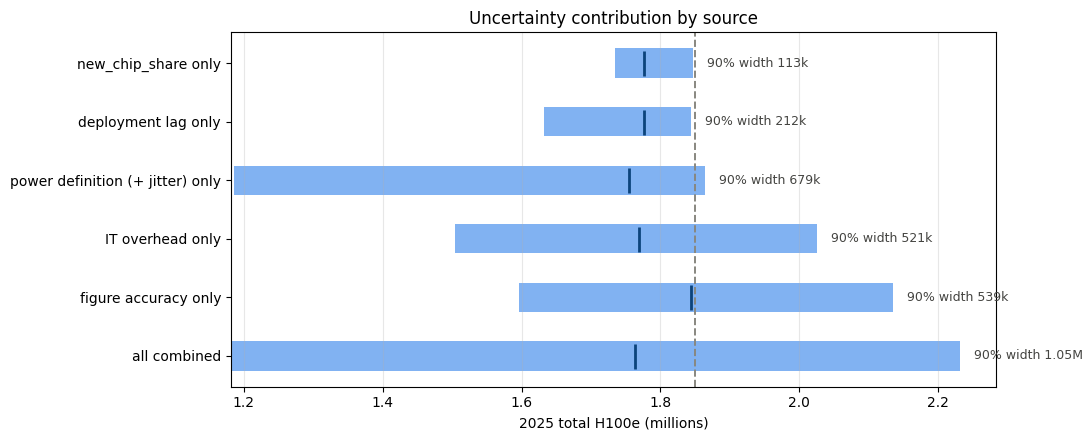

Latest-year total H100e by source (5th / median / 95th):
   new_chip_share only           : 1.74M / 1.78M / 1.85M
   deployment lag only           : 1.63M / 1.78M / 1.84M
   power definition (+ jitter) only: 1.19M / 1.76M / 1.86M
   IT overhead only              : 1.50M / 1.77M / 2.02M
   figure accuracy only          : 1.60M / 1.84M / 2.14M
   all combined                  : 1.18M / 1.76M / 2.23M


In [8]:
central_share = np.full(N_SAMPLES, new_chip_share_central)
central_lag = np.full(N_SAMPLES, lag_central)
central_overhead = np.full(N_SAMPLES, OVERHEAD_MEDIAN)
nominal_power = {d: np.full(N_SAMPLES, disclosed_power_mw[d]) for d in OPENAI_DATES}

# Nominal power scaled by one factor at a time (each a single shared draw across
# years). total_power can't be reused for the definition row: it now bundles the
# accuracy factor too.
accuracy_samples = figure_accuracy_prior @ N_SAMPLES
accuracy_only_power = {d: disclosed_power_mw[d] * accuracy_samples for d in OPENAI_DATES}
definition_samples = power_definition_factor @ N_SAMPLES
definition_jitter_power = {
    d: (disclosed_power_mw[d] + (sq.triangular(-ROUNDING_MW, 0, ROUNDING_MW) @ N_SAMPLES)) * definition_samples
    for d in OPENAI_DATES
}

decomposition = {
    'new_chip_share only': run_monte_carlo(new_chip_share, central_lag, nominal_power, central_overhead),
    'deployment lag only': run_monte_carlo(central_share, lag_quarters, nominal_power, central_overhead),
    'power definition (+ jitter) only': run_monte_carlo(central_share, central_lag, definition_jitter_power, central_overhead),
    'IT overhead only': run_monte_carlo(central_share, central_lag, nominal_power, it_overhead),
    'figure accuracy only': run_monte_carlo(central_share, central_lag, accuracy_only_power, central_overhead),
    'all combined': mc,
}

fig, ax = plt.subplots(figsize=(11, 4.5))
sources = list(decomposition)
for row, name in enumerate(sources):
    lo, mid, hi = percentiles(decomposition[name][last_date]['total_h100e'])
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#1a73e8', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#0c447c', markersize=18, markeredgewidth=2)
    ax.text((hi + 20000) / 1e6, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.axvline(reference_h100e[last_date] / 1e6, color='#888780', ls='--', lw=1.4)
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources)
ax.invert_yaxis()
ax.set_xlabel(f'{last_date.strftime("%Y")} total H100e (millions)')
ax.set_title('Uncertainty contribution by source', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Latest-year total H100e by source (5th / median / 95th):')
for name in sources:
    lo, mid, hi = percentiles(decomposition[name][last_date]['total_h100e'])
    print(f'   {name:30s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 7. Sensitivity to the `new_chip_share` prior

Re-run the full Monte Carlo (lag and power still varying, reusing the same
samples) under each candidate prior.

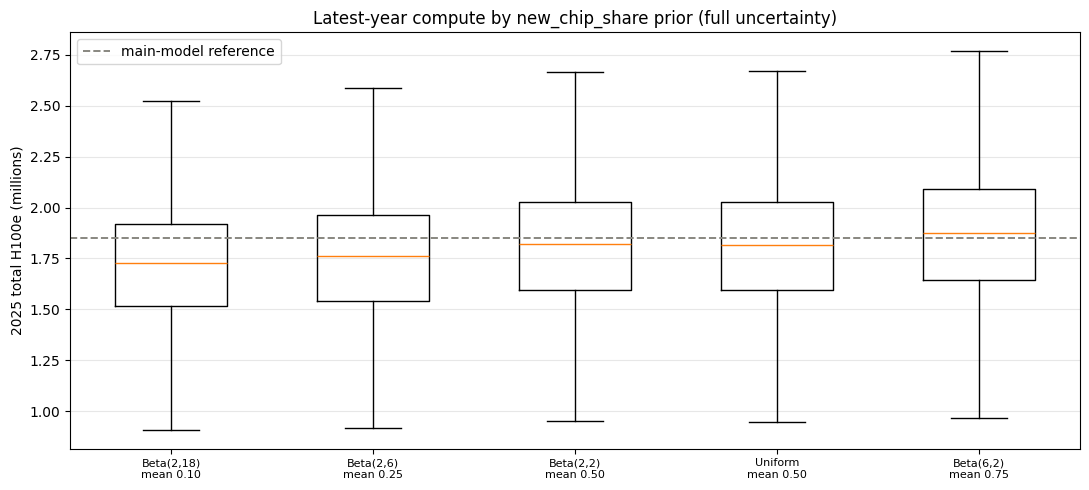

Latest-year total H100e by new_chip_share prior (5th / median / 95th):
   Beta(2,18) — mean 0.10  : 1.16M / 1.73M / 2.19M
   Beta(2,6) — mean 0.25   : 1.19M / 1.76M / 2.23M
   Beta(2,2) — mean 0.50   : 1.22M / 1.82M / 2.32M
   Uniform — mean 0.50     : 1.21M / 1.82M / 2.33M
   Beta(6,2) — mean 0.75   : 1.26M / 1.88M / 2.39M


In [9]:
priors = {
    'Beta(2,18) — mean 0.10': sq.beta(2, 18),
    'Beta(2,6) — mean 0.25': sq.beta(2, 6),
    'Beta(2,2) — mean 0.50': sq.beta(2, 2),
    'Uniform — mean 0.50': sq.uniform(0, 1),
    'Beta(6,2) — mean 0.75': sq.beta(6, 2),
}

prior_h100e = {
    name: run_monte_carlo(prior @ N_SAMPLES, lag_quarters, total_power, it_overhead)[last_date]['total_h100e']
    for name, prior in priors.items()
}

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([prior_h100e[name] / 1e6 for name in priors], showfliers=False, widths=0.55)
ax.set_xticks(range(1, len(priors) + 1))
ax.set_xticklabels([n.replace(' — ', '\n') for n in priors], fontsize=8)
ax.axhline(reference_h100e[last_date] / 1e6, color='#888780', ls='--', lw=1.4, label='main-model reference')
ax.set_ylabel(f'{last_date.strftime("%Y")} total H100e (millions)')
ax.set_title('Latest-year compute by new_chip_share prior (full uncertainty)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Latest-year total H100e by new_chip_share prior (5th / median / 95th):')
for name in priors:
    lo, mid, hi = percentiles(prior_h100e[name])
    print(f'   {name:24s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 8. Sensitivity to the gross-vs-IT split

The power definition factor assumes a 20% chance each disclosed figure is gross
(facility) power rather than IT. That split is a judgment call, so here we sweep
it: from 0% (always IT — the factor collapses to the tight residual band at 1.0)
up to 80% gross. More gross probability puts more weight on the 1/PUE haircut,
which pulls the total down and fattens its lower tail. `new_chip_share` and lag
keep varying (reusing the same samples); only the gross weight changes.

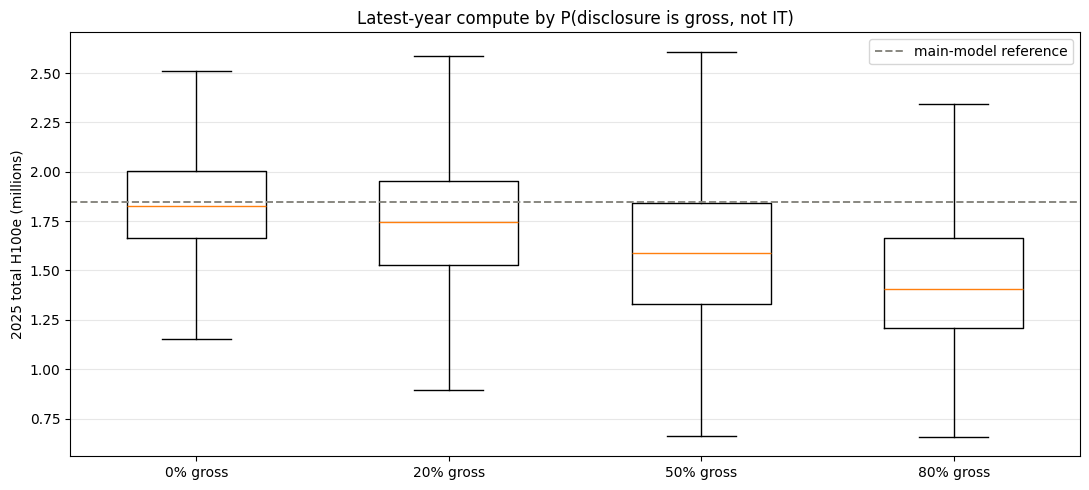

Latest-year total H100e by P(gross) (5th / median / 95th):
    0% gross: 1.44M / 1.83M / 2.27M
   20% gross: 1.17M / 1.75M / 2.25M
   50% gross: 1.05M / 1.59M / 2.17M
   80% gross: 989k / 1.41M / 2.04M


In [10]:
def total_power_with_gross_prob(n, p_gross):
    """Re-sample total power with a given probability that each disclosure is gross
    rather than IT. Same structure as sample_total_power (including the
    figure-accuracy factor), just a different gross weight."""
    factor = sq.mixture([if_it_power, if_gross_power], [1 - p_gross, p_gross])
    definition_factor = factor @ n
    accuracy_factor = figure_accuracy_prior @ n
    return {
        date: (disclosed_power_mw[date] + (sq.triangular(-ROUNDING_MW, 0, ROUNDING_MW) @ n))
        * definition_factor * accuracy_factor
        for date in OPENAI_DATES
    }


gross_probs = [0.0, 0.2, 0.5, 0.8]
gross_h100e = {
    p: run_monte_carlo(new_chip_share, lag_quarters, total_power_with_gross_prob(N_SAMPLES, p), it_overhead)[last_date]['total_h100e']
    for p in gross_probs
}

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([gross_h100e[p] / 1e6 for p in gross_probs], showfliers=False, widths=0.55)
ax.set_xticks(range(1, len(gross_probs) + 1))
ax.set_xticklabels([f'{int(p * 100)}% gross' for p in gross_probs])
ax.axhline(reference_h100e[last_date] / 1e6, color='#888780', ls='--', lw=1.4, label='main-model reference')
ax.set_ylabel(f'{last_date.strftime("%Y")} total H100e (millions)')
ax.set_title('Latest-year compute by P(disclosure is gross, not IT)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Latest-year total H100e by P(gross) (5th / median / 95th):')
for p in gross_probs:
    lo, mid, hi = percentiles(gross_h100e[p])
    print(f'   {int(p * 100):>2d}% gross: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

### Takeaways

- The biggest driver of total-compute uncertainty is the **power definition
  factor** — it scales the whole fleet, so its spread flows almost directly into
  the H100e total. Unlike the other knobs it is one-sided: the 20% chance a
  figure is gross rather than IT pulls a downward tail, so the interval is
  asymmetric (more room below the median than above).
- **`new_chip_share`** and the **deployment lag** move the total only modestly
  (the fleet is already mostly newest-vintage), but they are what reshape the
  **chip composition** — A100 vs. Blackwell share.
- Even sweeping the `new_chip_share` prior across its full range leaves the
  total in a fairly narrow band, so the headline number is robust; the chip mix
  is where the assumptions bite.
- Natural next addition: let watts per GPU vary, which feeds both the mix and
  the power-to-chip conversion.